# EDA за Flickr8k: Генериране на описание за изображение

В този notebook разглеждам данните стъпка по стъпка, преди да започна обучението на модела.  
Целта ми е да проверя структурата, качеството и основните характеристики на набора от данни.

Проверявам:

1. структура на файловете;
2. captions файла;
3. брой изображения и описания;
4. липсващи/дублирани стойности;
5. статистики за текста;
6. статистики за изображенията;
7. визуализации;
8. примерни изображения с captions;
9. изводи за preprocessing и моделиране.

## 0. Настройка

Използвам следната структура на Flickr8k:

```text
DATA/flickr8k/Images
DATA/flickr8k/captions.txt
```

Кодът поддържа и вариант, при който файлът с описанията е `captions.csv`.

In [1]:
import re 

In [2]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

print("imports")

# Намираме root директорията независимо откъде е стартиран notebook-ът.
PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "DATA" / "flickr8k").exists()
)
IMAGES_DIR = PROJECT_ROOT / "DATA" / "flickr8k" / "Images"
CAPTIONS_PATH = PROJECT_ROOT / "DATA" / "flickr8k" / "captions.txt"

print("dirs")


OUTPUT_DIR = PROJECT_ROOT / "reports" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not IMAGES_DIR.is_dir():
    raise FileNotFoundError(f"Images directory not found: {IMAGES_DIR}")
if not CAPTIONS_PATH.is_file():
    raise FileNotFoundError(f"Captions file not found: {CAPTIONS_PATH}")


imports
dirs


In [3]:
# Зареждам Flickr8k директно в стъпка 0.
captions = (
    pd.read_csv(CAPTIONS_PATH, sep="|")
    .rename(columns={"image_name": "image", "caption_text": "caption"})
    [["image", "caption"]]
    .dropna()
    .reset_index(drop=True)
)
image_paths = sorted(IMAGES_DIR.glob("*.jpg"))

print(f"Заредени captions: {len(captions):,}")
print(f"Уникални изображения: {captions['image'].nunique():,}")
print(f"Image файлове: {len(image_paths):,}")
print(f"Output директория: {OUTPUT_DIR}")
display(captions.head())

Заредени captions: 40,455
Уникални изображения: 8,091
Image файлове: 8,091
Output директория: /Users/nxics/Downloads/DL_25-26-main 2/reports/eda


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## 1. Помощни функции

Тук дефинирам помощните функции за tokenization и обработка на текста.

In [4]:
def tokenize(text: str) -> list[str]:
    """Simple tokenizer for English captions."""
    return re.findall(r"[a-zA-Z]+(?:'[a-zA-Z]+)?", str(text).lower())


def read_flickr8k_captions(captions_path: str | Path) -> pd.DataFrame:
    """Read Flickr8k captions from common Kaggle formats.

    Supported formats:
    1. CSV with columns: image, caption
    2. Legacy format: image_name.jpg#0<TAB>caption text
    3. Simple comma format: image_name.jpg,caption text
    """
    captions_path = Path(captions_path)
    if not captions_path.exists():
        raise FileNotFoundError(f"Caption file not found: {captions_path}")

    # First try regular CSV.
    try:
        frame = pd.read_csv(captions_path)
        if {"image", "caption"}.issubset(frame.columns):
            frame = frame[["image", "caption"]].dropna().reset_index(drop=True)
            frame["image"] = frame["image"].astype(str)
            frame["caption"] = frame["caption"].astype(str)
            return frame
    except Exception:
        pass

    rows = []
    with captions_path.open(encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue

            if "	" in line:
                image_part, caption = line.split("	", maxsplit=1)
            elif "," in line:
                image_part, caption = line.split(",", maxsplit=1)
            else:
                continue

            image_name = image_part.split("#")[0]
            rows.append({"image": image_name, "caption": caption})

    frame = pd.DataFrame(rows).dropna().reset_index(drop=True)
    frame["image"] = frame["image"].astype(str)
    frame["caption"] = frame["caption"].astype(str)
    return frame

## 2. Преглед на заредения dataset

Dataset-ът е зареден в стъпка 0. Тук проверявам размера му и колоните `image` и `caption`.

In [5]:
print("Shape:", captions.shape)
display(captions.head(10))

Shape: (40455, 2)


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


## 3. Базови проверки на данните

Проверявам за липсващи стойности, празни captions, дублирани редове и броя captions за всяко изображение.

In [6]:
basic_summary = {
    "caption_rows": len(captions),
    "unique_images_in_captions": captions["image"].nunique(),
    "missing_image_names": captions["image"].isna().sum(),
    "missing_captions": captions["caption"].isna().sum(),
    "empty_captions": captions["caption"].str.strip().eq("").sum(),
    "duplicate_rows": captions.duplicated().sum(),
}

pd.Series(basic_summary, name="value").to_frame()

,value
caption_rows,40455
unique_images_in_captions,8091
missing_image_names,0
missing_captions,0
empty_captions,0
duplicate_rows,10


In [ ]:
captions_per_image = captions.groupby("image")["caption"].count().sort_values(ascending=False)

print("Captions per image statistics:")
display(captions_per_image.describe().to_frame("captions_per_image"))

print("Images with unusual number of captions:")
display(captions_per_image[captions_per_image != captions_per_image.mode().iloc[0]].head(20).to_frame())

## 4. Проверка на файловете с изображения

Сравнявам имената от captions файла с реалните файлове в папката с изображения, за да открия липсващи или излишни файлове.

In [7]:
image_files = sorted([
    path.name for path in IMAGES_DIR.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
]) if IMAGES_DIR.exists() else []

caption_image_names = set(captions["image"].unique())
actual_image_names = set(image_files)

missing_images = sorted(caption_image_names - actual_image_names)
extra_images = sorted(actual_image_names - caption_image_names)

image_file_summary = {
    "actual_image_files": len(actual_image_names),
    "images_referenced_in_captions": len(caption_image_names),
    "missing_images": len(missing_images),
    "extra_images_not_in_captions": len(extra_images),
}

pd.Series(image_file_summary, name="value").to_frame()

,value
actual_image_files,8091
images_referenced_in_captions,8091
missing_images,0
extra_images_not_in_captions,0


In [8]:
print("First missing images:")
display(pd.DataFrame({"missing_image": missing_images[:20]}))

print("First extra images:")
display(pd.DataFrame({"extra_image": extra_images[:20]}))

First missing images:


,missing_image


First extra images:


,extra_image


## 5. Статистики за captions

Изчислявам дължината на captions, броя уникални думи и честотата на думите. Използвам тези резултати при избора на vocabulary, padding и максимална дължина.

In [9]:
captions = captions.copy()
captions["tokens"] = captions["caption"].map(tokenize)
captions["caption_length"] = captions["tokens"].map(len)

caption_stats = captions["caption_length"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("caption_length")
display(caption_stats)

,caption_length
count,40455.000000
mean,10.812631
std,3.767505
min,1.000000
5%,6.000000
25%,8.000000
50%,10.000000
75%,13.000000
95%,18.000000
max,36.000000


In [10]:
all_tokens = [token for tokens in captions["tokens"] for token in tokens]
word_counts = Counter(all_tokens)

vocab_summary = {
    "total_tokens": len(all_tokens),
    "unique_tokens": len(word_counts),
    "tokens_with_frequency_1": sum(1 for _, count in word_counts.items() if count == 1),
    "tokens_with_frequency_at_least_5": sum(1 for _, count in word_counts.items() if count >= 5),
    "tokens_with_frequency_at_least_10": sum(1 for _, count in word_counts.items() if count >= 10),
}

pd.Series(vocab_summary, name="value").to_frame()

,value
total_tokens,437425
unique_tokens,8442
tokens_with_frequency_1,3310
tokens_with_frequency_at_least_5,2970
tokens_with_frequency_at_least_10,1961


In [11]:
top_words = pd.DataFrame(word_counts.most_common(30), columns=["word", "count"])
display(top_words)

,word,count
0,a,62992
1,in,18986
2,the,18419
3,on,10745
4,is,9345
5,and,8862
6,dog,8138
7,with,7765
8,man,7274
9,of,6723


## 6. Визуализации за captions

Визуализирам разпределението на дължините и най-често срещаните думи. Тези графики използвам и в представянето на проекта.

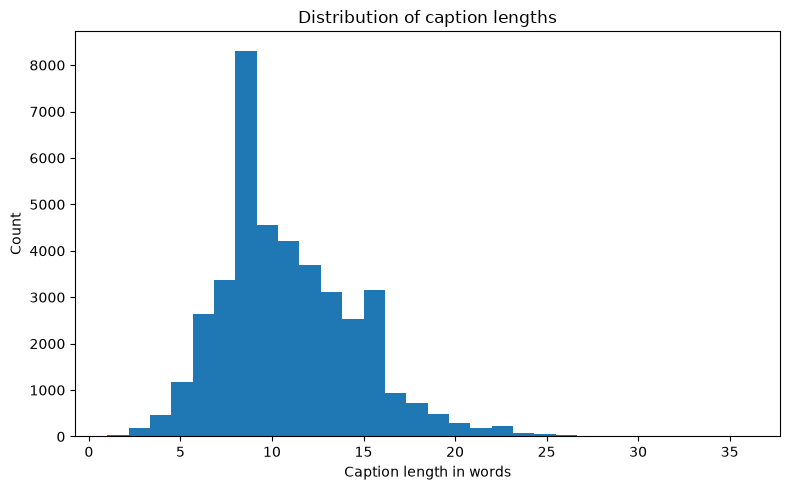

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(captions["caption_length"], bins=30)
plt.xlabel("Caption length in words")
plt.ylabel("Count")
plt.title("Distribution of caption lengths")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "caption_length_distribution.png", dpi=150)
plt.show()

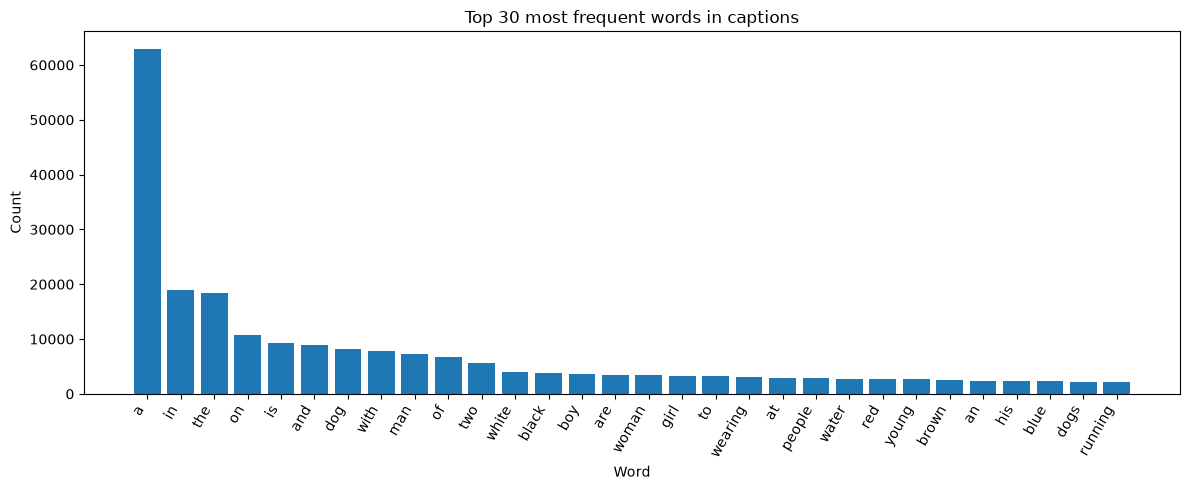

In [13]:
plt.figure(figsize=(12, 5))
plt.bar(top_words["word"], top_words["count"])
plt.xticks(rotation=60, ha="right")
plt.xlabel("Word")
plt.ylabel("Count")
plt.title("Top 30 most frequent words in captions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_30_words.png", dpi=150)
plt.show()

## 7. Най-къси и най-дълги captions

Преглеждам най-късите и най-дългите captions, за да открия потенциални аномалии и да преценя необходимостта от truncation.

In [14]:
print("Shortest captions:")
display(captions.sort_values("caption_length").head(10)[["image", "caption", "caption_length"]])

print("Longest captions:")
display(captions.sort_values("caption_length", ascending=False).head(10)[["image", "caption", "caption_length"]])

Shortest captions:


,image,caption,caption_length
33360,3640443200_b8066f37f6.jpg,a,1
9305,2428275562_4bde2bc5ea.jpg,A,1
23226,3237760601_5334f3f3b5.jpg,A skier,2
21250,3154693053_cfcd05c226.jpg,A basketball,2
13730,2714703706_d21c5cb8df.jpg,dogs playing,2
29287,3479245321_6a5bc470f8.jpg,Concentration campsite .,2
25769,3340857141_85d97a7466.jpg,Two dogs .,2
30876,3541915243_956c1aa8ef.jpg,Asian spectators .,2
5585,2165461920_1a4144eb2b.jpg,dogs racing,2
22088,3189251454_03b76c2e92.jpg,dog barking,2


Longest captions:


,image,caption,caption_length
8049,2354456107_bf5c766a05.jpg,An African-American man wearing a green sweats...,36
1325,130211457_be3f6b335d.jpg,A girl in a red and black leotard with white w...,33
2596,1472249944_d887c3aeda.jpg,A woman in an orange coat and jeans is squatti...,33
2730,1499495021_d295ce577c.jpg,A dark haired woman wearing a brown jacket and...,33
17731,2970461648_fe14ba0359.jpg,a young child in a t-shirt on a bike stands in...,32
13244,2687328779_b4356dab16.jpg,"While one white dog is outside the pool , anot...",32
14535,2774430374_fee1d793e7.jpg,A little boy holds a bat waiting for the pitch...,31
14244,2752809449_632cd991b3.jpg,A woman with a ponytail dressed in jean shorts...,31
30553,3530843182_35af2c821c.jpg,a man with sunglasses on his head is looking a...,31
25248,3322443827_a04a94bb91.jpg,A well-groomed young man wearing dark trousers...,31


## 8. Статистики за изображенията

Извличам ширина, височина, aspect ratio и image mode. Използвам статистиките, за да избера resize стратегията към вход `224x224` за VGG16.

In [15]:
image_rows = []
corrupted_images = []

for image_name in sorted(caption_image_names):
    image_path = IMAGES_DIR / image_name
    if not image_path.exists():
        continue

    try:
        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode
        image_rows.append({
            "image": image_name,
            "width": width,
            "height": height,
            "aspect_ratio": width / height if height else np.nan,
            "mode": mode,
        })
    except (UnidentifiedImageError, OSError) as error:
        corrupted_images.append({"image": image_name, "error": str(error)})

images = pd.DataFrame(image_rows)
corrupted = pd.DataFrame(corrupted_images)

print("Loaded image metadata:", images.shape)
print("Corrupted images:", len(corrupted))
display(images.head())

Loaded image metadata: (8091, 5)
Corrupted images: 0


,image,width,height,aspect_ratio,mode
0,1000268201_693b08cb0e.jpg,375,500,0.750000,RGB
1,1001773457_577c3a7d70.jpg,500,375,1.333333,RGB
2,1002674143_1b742ab4b8.jpg,500,400,1.250000,RGB
3,1003163366_44323f5815.jpg,500,410,1.219512,RGB
4,1007129816_e794419615.jpg,500,461,1.084599,RGB


In [16]:
if not images.empty:
    display(images[["width", "height", "aspect_ratio"]].describe().T)
    display(images["mode"].value_counts().to_frame("count"))
else:
    print("No image metadata loaded. Check IMAGES_DIR.")

,count,mean,std,min,25%,50%,75%,max
width,8091.0,457.872204,68.659411,164.000,400.0,500.000000,500.000000,500.000000
height,8091.0,397.251885,75.670168,127.000,333.0,375.000000,500.000000,500.000000
aspect_ratio,8091.0,1.219682,0.361616,0.328,0.8,1.333333,1.501502,3.937008


,count
mode,
RGB,8091


## 9. Визуализации за изображенията

Разглеждам разпределенията на размерите и aspect ratio. При resize към квадрат част от изображенията се деформират, но за базовия модел приемам този компромис.

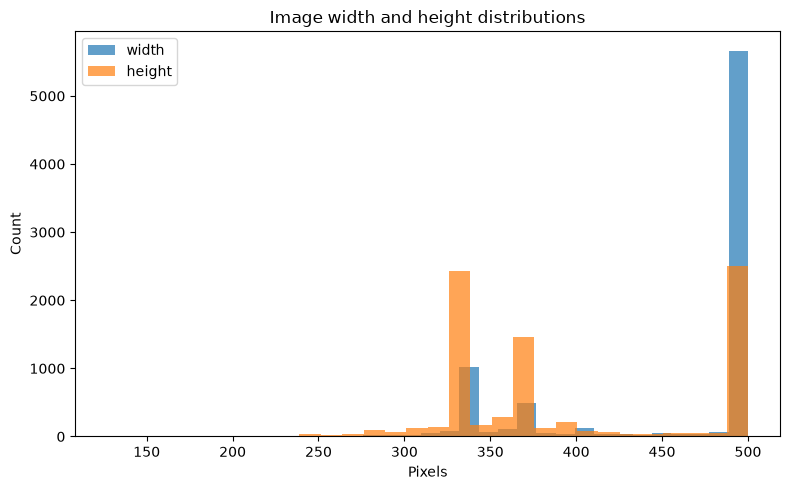

In [17]:
if not images.empty:
    plt.figure(figsize=(8, 5))
    plt.hist(images["width"], bins=30, alpha=0.7, label="width")
    plt.hist(images["height"], bins=30, alpha=0.7, label="height")
    plt.xlabel("Pixels")
    plt.ylabel("Count")
    plt.title("Image width and height distributions")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "image_width_height_distribution.png", dpi=150)
    plt.show()

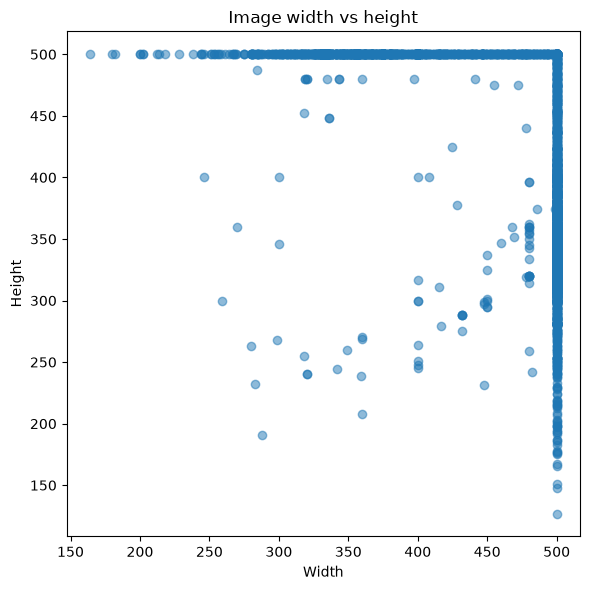

In [18]:
if not images.empty:
    plt.figure(figsize=(6, 6))
    plt.scatter(images["width"], images["height"], alpha=0.5)
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.title("Image width vs height")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "image_width_vs_height.png", dpi=150)
    plt.show()

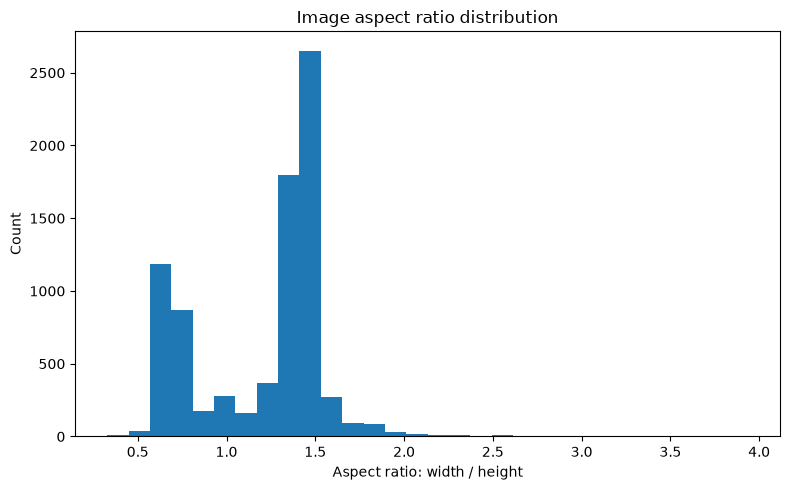

In [19]:
if not images.empty:
    plt.figure(figsize=(8, 5))
    plt.hist(images["aspect_ratio"], bins=30)
    plt.xlabel("Aspect ratio: width / height")
    plt.ylabel("Count")
    plt.title("Image aspect ratio distribution")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "image_aspect_ratio_distribution.png", dpi=150)
    plt.show()

## 10. Примерни изображения с captions

Показвам примерни изображения заедно с техните captions, за да проверя визуално дали описанията съответстват на съдържанието.

Available images: 8091


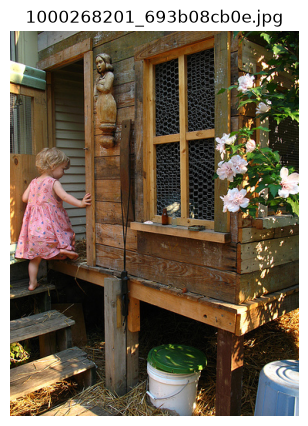

1. A child in a pink dress is climbing up a set of stairs in an entry way .
2. A girl going into a wooden building .
3. A little girl climbing into a wooden playhouse .
4. A little girl climbing the stairs to her playhouse .
5. A little girl in a pink dress going into a wooden cabin .
--------------------------------------------------------------------------------


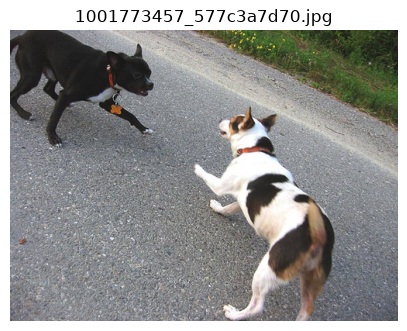

1. A black dog and a spotted dog are fighting
2. A black dog and a tri-colored dog playing with each other on the road .
3. A black dog and a white dog with brown spots are staring at each other in the street .
4. Two dogs of different breeds looking at each other on the road .
5. Two dogs on pavement moving toward each other .
--------------------------------------------------------------------------------


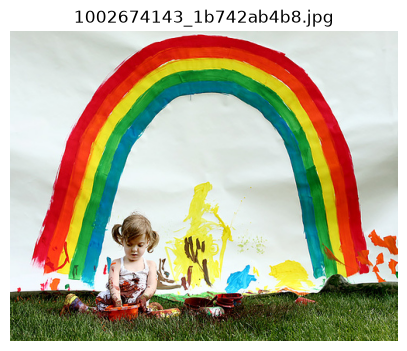

1. A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
2. A little girl is sitting in front of a large painted rainbow .
3. A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .
4. There is a girl with pigtails sitting in front of a rainbow painting .
5. Young girl with pigtails painting outside in the grass .
--------------------------------------------------------------------------------


In [20]:
def show_image_with_captions(image_name: str) -> None:
    image_path = IMAGES_DIR / image_name
    image_captions = captions.loc[captions["image"] == image_name, "caption"].tolist()

    with Image.open(image_path) as img:
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(image_name)
        plt.show()

    for index, caption in enumerate(image_captions, start=1):
        print(f"{index}. {caption}")


available_images = sorted(caption_image_names & actual_image_names)
print("Available images:", len(available_images))

# Показвам 3 примерни изображения.
for image_name in available_images[:3]:
    show_image_with_captions(image_name)
    print("-" * 80)

## 11. Галерия от случайни изображения

Показвам малка случайна извадка от изображенията. Галерията може да се използва при представянето на проекта.

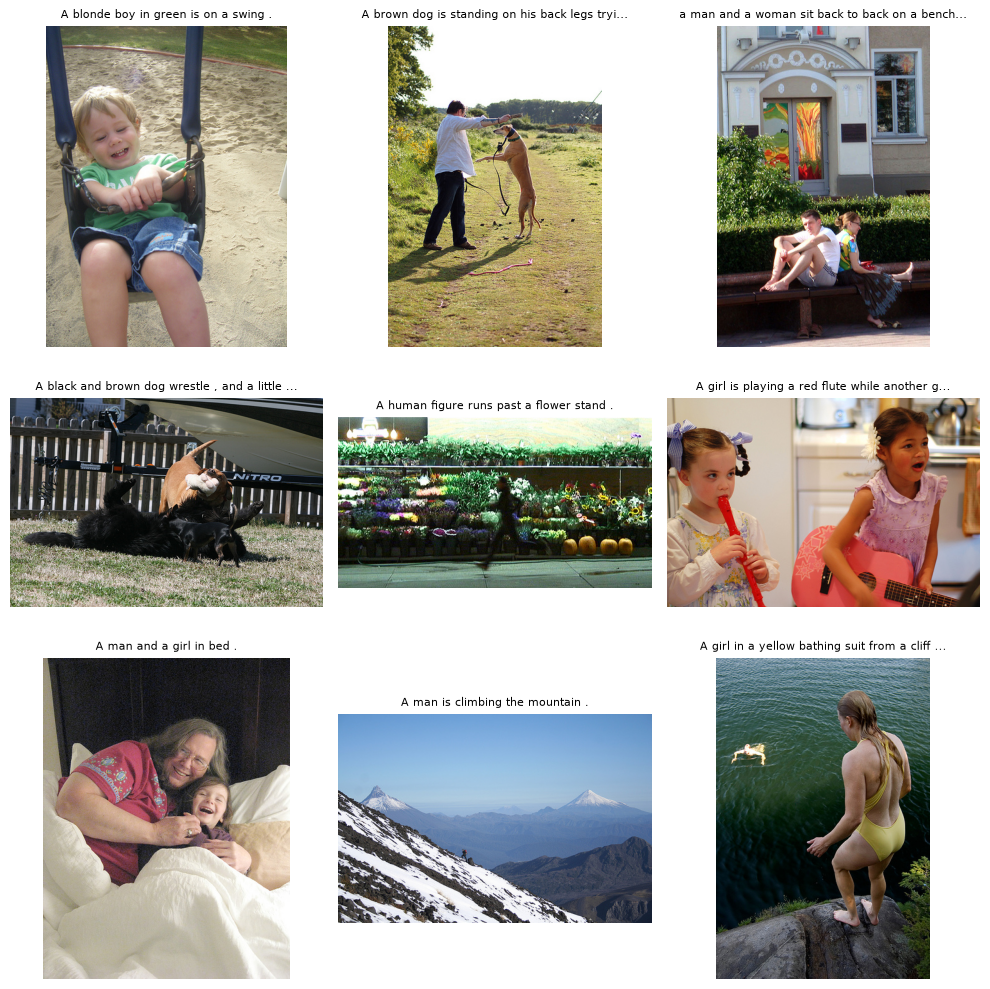

In [21]:
rng = np.random.default_rng(42)

if available_images:
    sample_size = min(9, len(available_images))
    sample_images = rng.choice(available_images, size=sample_size, replace=False)

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.ravel()

    for ax, image_name in zip(axes, sample_images):
        image_path = IMAGES_DIR / image_name
        with Image.open(image_path) as img:
            ax.imshow(img)
        first_caption = captions.loc[captions["image"] == image_name, "caption"].iloc[0]
        ax.set_title(first_caption[:45] + ("..." if len(first_caption) > 45 else ""), fontsize=8)
        ax.axis("off")

    for ax in axes[sample_size:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "sample_image_gallery.png", dpi=150)
    plt.show()
else:
    print("No available images found.")

## 12. Проверка за дублирани captions и потенциално generic описания

Проверявам колко често се срещат общи описания като “a man is standing”. Високата им честота може да насочи модела към генериране на по-общи и по-малко информативни captions.

In [22]:
duplicate_caption_counts = captions["caption"].value_counts()
frequent_duplicate_captions = duplicate_caption_counts[duplicate_caption_counts > 1].head(20)

display(frequent_duplicate_captions.to_frame("count"))

,count
caption,
Two dogs playing in the snow .,7
two dogs play together .,6
A dog runs through the grass .,6
A dog swimming with a stick in its mouth .,6
A person on a bmx bike .,6
Two dogs play in the grass .,5
Two dogs run through a field .,5
a dog runs across the grass .,4
A dog in the snow .,4


In [23]:
generic_patterns = [
    "a man", "a woman", "a dog", "a child", "a person", "people are", "is standing", "is sitting"
]

generic_rows = []
for pattern in generic_patterns:
    count = captions["caption"].str.lower().str.contains(pattern, regex=False).sum()
    generic_rows.append({"pattern": pattern, "count": int(count), "share": count / len(captions)})

pd.DataFrame(generic_rows).sort_values("count", ascending=False)

,pattern,count,share
0,a man,5020,0.124088
1,a woman,2177,0.053813
2,a dog,1984,0.049042
4,a person,1137,0.028105
3,a child,821,0.020294
5,people are,610,0.015078
6,is standing,533,0.013175
7,is sitting,370,0.009146


## 13. Запазване на обобщение за доклада

Записвам обобщението и допълнителните таблици като CSV файлове, за да ги използвам в анализа и представянето на проекта.

In [24]:
summary = {
    **basic_summary,
    **image_file_summary,
    **vocab_summary,
    "caption_length_min": float(captions["caption_length"].min()),
    "caption_length_mean": float(captions["caption_length"].mean()),
    "caption_length_median": float(captions["caption_length"].median()),
    "caption_length_max": float(captions["caption_length"].max()),
}

if not images.empty:
    summary.update({
        "image_width_mean": float(images["width"].mean()),
        "image_height_mean": float(images["height"].mean()),
        "aspect_ratio_mean": float(images["aspect_ratio"].mean()),
    })

summary_frame = pd.Series(summary, name="value").to_frame()
summary_frame.to_csv(OUTPUT_DIR / "eda_summary.csv")
top_words.to_csv(OUTPUT_DIR / "top_words.csv", index=False)

if not images.empty:
    images.to_csv(OUTPUT_DIR / "image_metadata.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)
display(summary_frame)

Saved outputs to: /Users/nxics/Downloads/DL_25-26-main 2/reports/eda


,value
caption_rows,40455.000000
unique_images_in_captions,8091.000000
missing_image_names,0.000000
missing_captions,0.000000
empty_captions,0.000000
duplicate_rows,10.000000
actual_image_files,8091.000000
images_referenced_in_captions,8091.000000
missing_images,0.000000
extra_images_not_in_captions,0.000000


## 14. Коментари и изводи за проекта

В тази секция обобщавам основните наблюдения и решения след изпълнението на анализа.

### Наблюдения

- Flickr8k съдържа 8091 изображения и приблизително 5 captions за всяко изображение.
- Описанията са кратки и обикновено описват ясно видима сцена или действие.
- Най-често срещаните думи са свързани с хора, кучета, движение, цветове и outdoor сцени.
- Проверявам липсващи изображения, празни captions, дублирани редове и image metadata.
- Запазвам резултатите в `reports/eda/`, за да ги използвам в доклада и презентацията.

### Изводи за preprocessing

- Използвам `Resize((224, 224))`, защото VGG16 работи с такъв вход.
- Използвам ImageNet normalization, за да е съвместимо preprocessing-ът с предварително обучен VGG16.
- Добавям `<start>`, `<end>`, `<pad>` и `<unk>` tokens за sequence modeling.
- Ограничавам vocabulary с `min_freq=5`, за да намаля много редките думи.
- Избирам максимална дължина на caption според разпределението на дължините и използвам padding.

### Изводи за augmentation

- Augmentation се прилага само върху train split-а.
- Основните операции са `RandomHorizontalFlip` и малък `RandomRotation`.
- Validation и test preprocessing са детерминирани, за да не се променя оценката между различни изпълнения.

### Изводи за моделиране

- EDA подкрепя избора на VGG16 encoder и LSTM decoder като ясен baseline.
- Поради малкия dataset очаквам baseline моделът да работи по-добре върху сцени, близки до Flickr8k.
- По-късно в modeling notebook-а сравнявам основния модел с VGG retrieval и предварително обучен BLIP режим.

## 15. Ограничения от EDA и връзка с качеството на captions

От EDA се вижда, че Flickr8k не е универсален dataset за всички видове изображения. Данните са сравнително малко за image captioning задача и голяма част от captions описват типични outdoor сцени: хора, деца, кучета, спорт, движение и групи от хора.

Това има директен ефект върху Streamlit приложението. Ако подам произволна лична снимка, която е далеч от разпределението на Flickr8k — например screenshot, снимка на стая, храна, документ, предмет на бюро или много специфична сцена — моделът често генерира общ caption. Това е очаквано ограничение на dataset-а и архитектурата, не задължително грешка в кода.

Затова за демонстрация най-подходящи са снимки, близки до dataset-а:

- човек или група хора навън;
- куче, което тича или играе;
- дете на площадка;
- спортна или outdoor сцена;
- сцена с ясно видим основен обект и проста композиция.

Този извод е отразен и в modeling notebook-а. Там основният VGG16 + LSTM модел е оставен като проектен baseline, а Streamlit приложението включва още VGG retrieval режим и BLIP режим за сравнение. Така презентацията може честно да покаже както собствения модел, така и причините защо при произволни изображения качеството не винаги е надеждно.